# Машинное обучение для определения спама в СМС-сообщениях и E-mail
Выполнили:

Воронова Алиса,
Швецова Анастасия,
Грибушенков Михаил (РФЗ-2-2022)

## Цель проекта

Обучить модель предсказывать по тексту сообщения, является ли оно спамом (`spam`) или обычным сообщением (`ham`).

## Используемый набор данных

- spam.csv (база СМС-сообщений: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)


## Содержание

1. Загрузка и проверка данных
2. EDA и визуализации, частотный анализ слов в сообщениях
3. Деление на обучающий и тестовый датасет
4. Сравнение моделей и векторизаций
5. Дополнительные эксперименты с дисбалансом классов и кластеризацией
6. Анализ ошибок лучшей модели
7. Финальные выводы

Аналогичная обработка другого набора данных - с E-mail - находится в отдельном блокноте для упрощения навигации: email_spam_final_project.ipynb


In [ ]:
#Includes
import re
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from wordcloud import WordCloud

from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Config

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

# Defines
DATA_PATH = "spam.csv"

## 1. Загрузка и проверка данных

- загрузим данные из .csv
- оставим только полезные столбцы
- проверим пропуски и дубликаты

В `spam.csv` есть два содержательных столбца:

- `v1` — класс (`ham` или `spam`)
- `v2` — текст сообщения

Пустые столбцы появились при конвертации и в анализе не нужны.


In [ ]:
# Загрузка базы данных
raw_df = pd.read_csv(DATA_PATH, encoding = "latin1", sep=",")
raw_df.head(3)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply ...,NaN,NaN,NaN


In [ ]:
df = raw_df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"}).copy()

csv_line_count = sum(1 for _ in open(DATA_PATH, encoding="latin1"))

quality_summary = pd.DataFrame(
    {
        "Показатель": [
            "Строк в локальном файле spam.csv",
            "Сообщений в DataFrame",
            "Пропуски в label",
            "Пропуски в text",
            "Полные дубликаты",
        ],
        "Значение": [
            csv_line_count,
            len(df),
            int(df["label"].isna().sum()),
            int(df["text"].isna().sum()),
            int(df.duplicated().sum()),
        ],
    }
)

display(quality_summary)
display(df.head(3))


,Показатель,Значение
0,Строк в локальном файле spam.csv,5575
1,Сообщений в DataFrame,5572
2,Пропуски в label,0
3,Пропуски в text,0
4,Полные дубликаты,403


,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply ...


**Вывод.** В локальном `spam.csv` получилось `5572` сообщений; видно, что пропусков нет, а вот дубликаты есть, поэтому их логично убрать перед обучением моделей.


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
class_counts = df["label"].value_counts().rename_axis("Класс").reset_index(name="Количество")
class_counts["Процент"] = class_counts["Количество"] / len(df) * 100

print(f"Размер после удаления дубликатов: {df.shape}")
display(class_counts)


Размер после удаления дубликатов: (5169, 2)


,Класс,Количество,Процент
0,ham,4516,87.3670
1,spam,653,12.6330


**Вывод.** После удаления дубликатов осталось `5169` уникальных сообщений. Класс `ham` заметно преобладает, то есть задача действительно несбалансированная. Это хорошо согласуется с планом проекта, где отдельно предлагается проверить влияние дисбаланса классов.


До построения моделей полезно посмотреть на реальные SMS. Так становится понятнее, что именно мы пытаемся различать.


In [ ]:
rng = 42
sample_ham = df[df["label"] == "ham"].sample(3, random_state=rng)[["label", "text"]]
sample_spam = df[df["label"] == "spam"].sample(3, random_state=rng)[["label", "text"]]

print("Примеры обычных сообщений (ham):")
display(sample_ham.reset_index(drop=True))
print("Примеры спам-сообщений (spam):")
display(sample_spam.reset_index(drop=True))


Примеры обычных сообщений (ham):


,label,text
0,ham,"Come to me, slave. Your doing it again ... Going into your shell and unconsciously avoiding me ... You are making me unhappy :-("
1,ham,U meet other fren dun wan meet me ah... Muz b a guy rite...
2,ham,"G says you never answer your texts, confirm/deny"


Примеры спам-сообщений (spam):


,label,text
0,spam,"Romantic Paris. 2 nights, 2 flights from å£79 Book now 4 next year. Call 08704439680Ts&Cs apply."
1,spam,"URGENT! Your mobile No *********** WON a å£2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! Call 09066362220 ..."
2,spam,Free 1st week entry 2 TEXTPOD 4 a chance 2 win 40GB iPod or å£250 cash every wk. Txt POD to 84128 Ts&Cs www.textpod.net custcare 0871240...


**Вывод.** Уже на уровне примеров видно, что спам чаще содержит призывы к действию, денежные суммы, ссылки, промо-лексикон и больше служебных символов. Обычные сообщения обычно короче и ближе к естественной бытовой переписке.


## 2. EDA и визуализации

Добавим в датасет несколько числовых признаков:

- длина текста в символах
- длина текста в словах
- число восклицательных знаков
- число цифр

Проверим, могут ли простые признаки хорошо показать различия между `ham` и `spam`.


In [ ]:
df["Число символов"] = df["text"].str.len()
df["Число слов"] = df["text"].str.split().str.len()
df["Число '!'"] = df["text"].str.count(r"!")
df["Число цифр"] = df["text"].str.count(r"\d")

summary_by_label = (
    df.groupby("label")[["Число символов", "Число слов", "Число '!'", "Число цифр"]]
    .agg(["mean", "median"])
    .round(2)
)
display(summary_by_label)


Число символов          Число слов         Число '!'        Число цифр  \
                mean   median       mean  median      mean median       mean   
label                                                                          
ham          70.4600  52.0000    14.1300 11.0000    0.1700 0.0000     0.2900   
spam        137.8900 149.0000    23.6800 25.0000    0.6900 0.0000    15.4500   

               
       median  
label          
ham    0.0000  
spam  16.0000

**Вывод.** Спам в среднем заметно длиннее обычных сообщений и по символам, и по словам. Кроме того, в нём чаще встречаются цифры и восклицательные знаки, что хорошо соответствует интуитивной картине рекламных и мошеннических SMS.


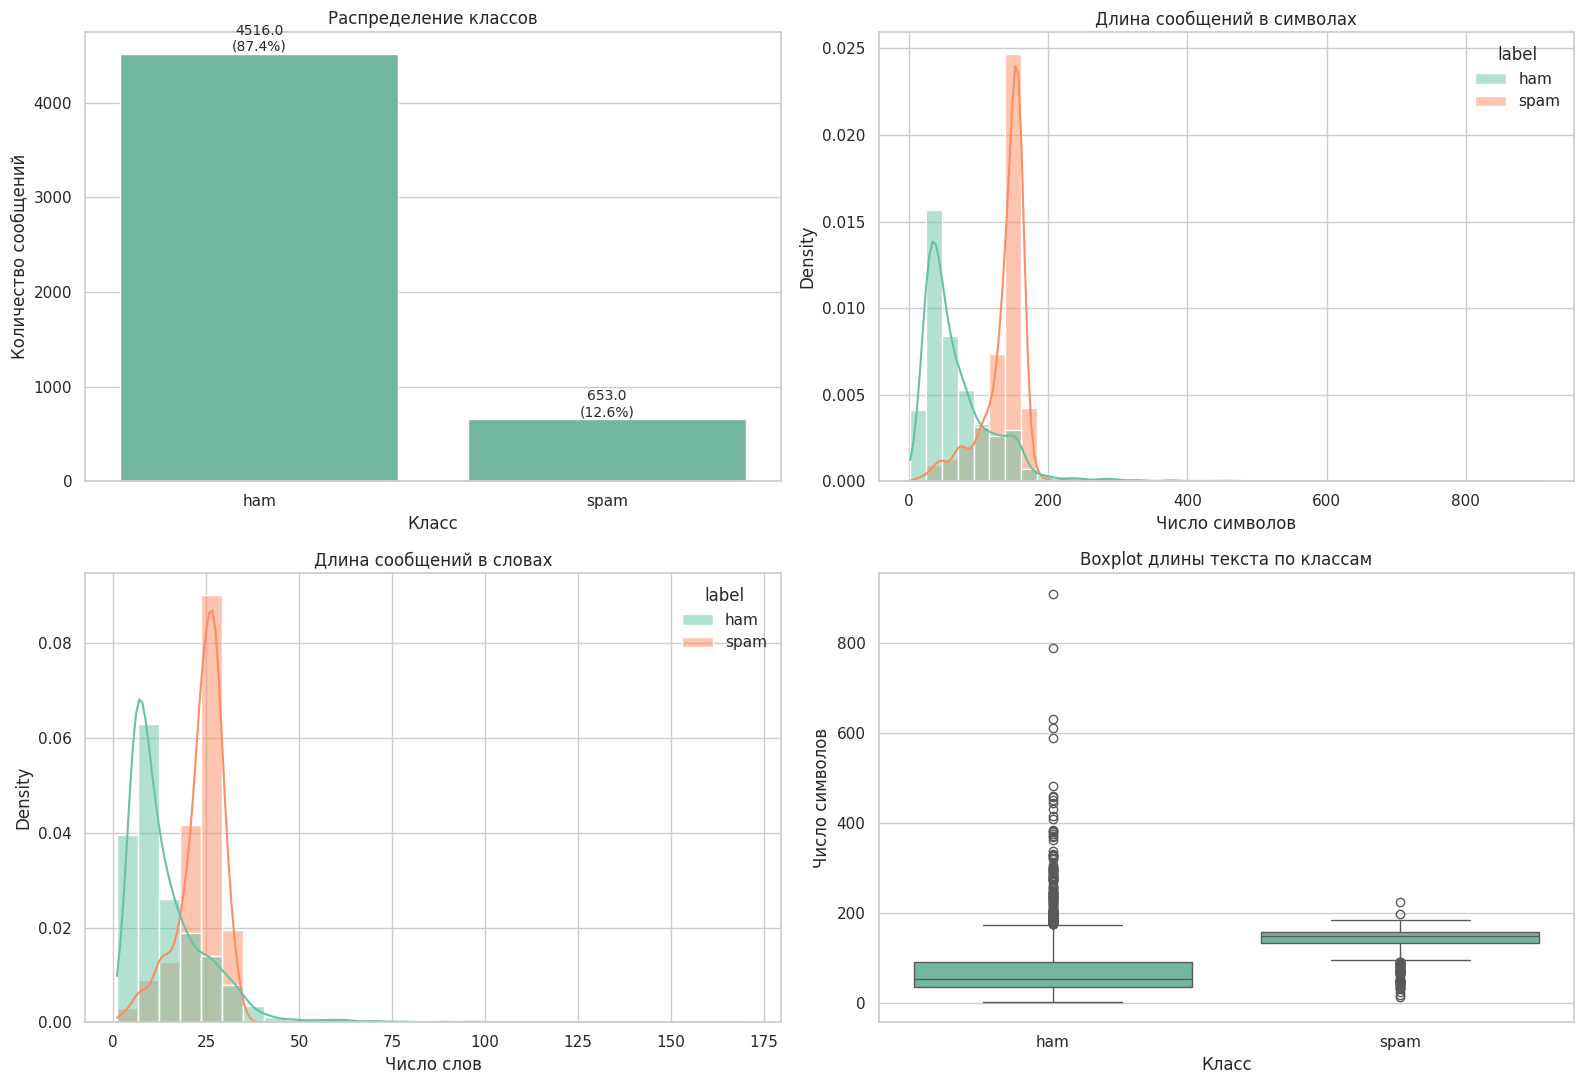

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

class_plot = sns.countplot(data=df, x="label", order=["ham", "spam"], ax=axes[0, 0])
axes[0, 0].set_title("Распределение классов")
axes[0, 0].set_xlabel("Класс")
axes[0, 0].set_ylabel("Количество сообщений")
total = len(df)
for patch in class_plot.patches:
    height = patch.get_height()
    pct = height / total * 100
    class_plot.annotate(
        f"{height}\n({pct:.1f}%)",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
    )

sns.histplot(
    data=df,
    x="Число символов",
    hue="label",
    bins=40,
    kde=True,
    stat="density",
    common_norm=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Длина сообщений в символах")
axes[0, 1].set_xlabel("Число символов")

sns.histplot(
    data=df,
    x="Число слов",
    hue="label",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Длина сообщений в словах")
axes[1, 0].set_xlabel("Число слов")

sns.boxplot(data=df, x="label", y="Число символов", order=["ham", "spam"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot длины текста по классам")
axes[1, 1].set_xlabel("Класс")
axes[1, 1].set_ylabel("Число символов")

plt.tight_layout()
plt.show()


**Вывод.** На графиках хорошо видны две вещи:

- классы несбалансированы: обычных сообщений намного больше
- спам сдвинут вправо по длине текста, то есть такие сообщения обычно длиннее

Это полезно для интерпретации будущих результатов модели: часть различий между классами объясняется уже на уровне структуры текста.


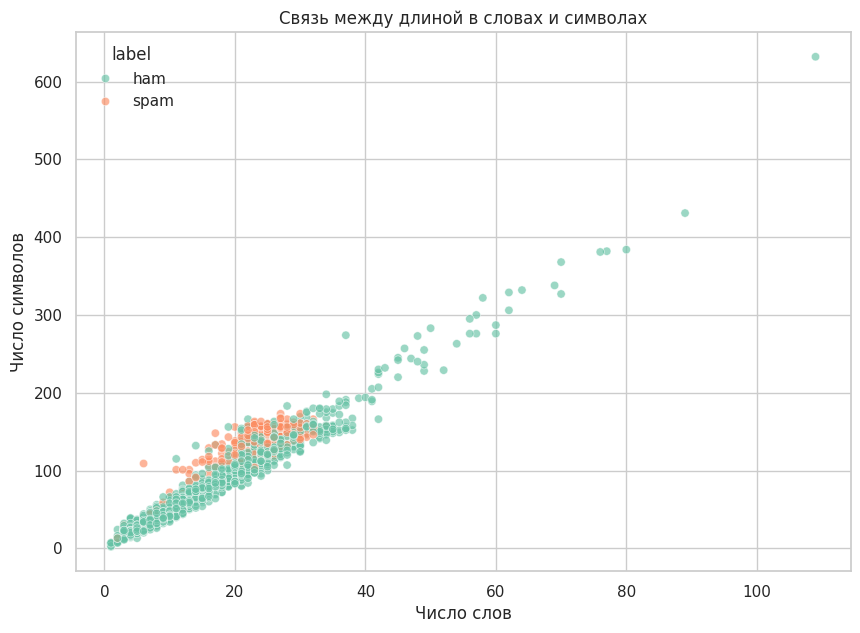

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df.sample(min(len(df), 2000), random_state=42),
    x="Число слов",
    y="Число символов",
    hue="label",
    alpha=0.65,
)
plt.title("Связь между длиной в словах и символах")
plt.xlabel("Число слов")
plt.ylabel("Число символов")
plt.show()


**Вывод.** Даже в двумерном пространстве длины сообщений спам частично отделяется от обычных SMS. Но полного разделения нет, поэтому для хорошего качества модели нам всё равно нужен анализ самих слов и выражений.


Предобработаем текстовые данные в сообщениях:
- переведем в нижний регистр
- удалим пунктуации и лишние символы
- удалим лишние пробелы
- отдельно удалим стоп-слова (особенно часто встречающиеся в английском языке слова, в т.ч. различные связки, не несущих особой смысловой нагрузки) и после отдельно проверим, помогает ли это.


In [ ]:
def clean_text(text: str, remove_stopwords: bool = False) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    if remove_stopwords:
        tokens = [token for token in text.split() if token not in ENGLISH_STOP_WORDS]
        text = " ".join(tokens)

    return text


df["text_clean_basic"] = df["text"].apply(clean_text)
df["text_clean_stop"] = df["text"].apply(lambda x: clean_text(x, remove_stopwords=True))

preview = df[["text", "text_clean_basic", "text_clean_stop"]].sample(3, random_state=73)
display(preview.reset_index(drop=True))


,text,text_clean_basic,text_clean_stop
0,Yup i thk so until e shop closes lor.,yup i thk so until e shop closes lor,yup thk e shop closes lor
1,Mm not entirely sure i understood that text but hey. Ho. Which weekend?,mm not entirely sure i understood that text but hey ho which weekend,mm entirely sure understood text hey ho weekend
2,"Im sorry bout last nite it wasnåÕt ur fault it was me, spouse it was pmt or sumthin! U 4give me? I think u shldxxxx",im sorry bout last nite it wasn t ur fault it was me spouse it was pmt or sumthin u 4give me i think u shldxxxx,im sorry bout nite wasn t ur fault spouse pmt sumthin u 4give think u shldxxxx


**Вывод.** После очистки текст становится заметно более удобным для векторизации: исчезают регистр, лишняя пунктуация и шум. Вариант со стоп-словами делает текст ещё компактнее, но это не всегда означает улучшение качества, поэтому ниже мы сравним оба подхода экспериментально.


Посмотрим, какие слова чаще встречаются в `ham` и `spam`.


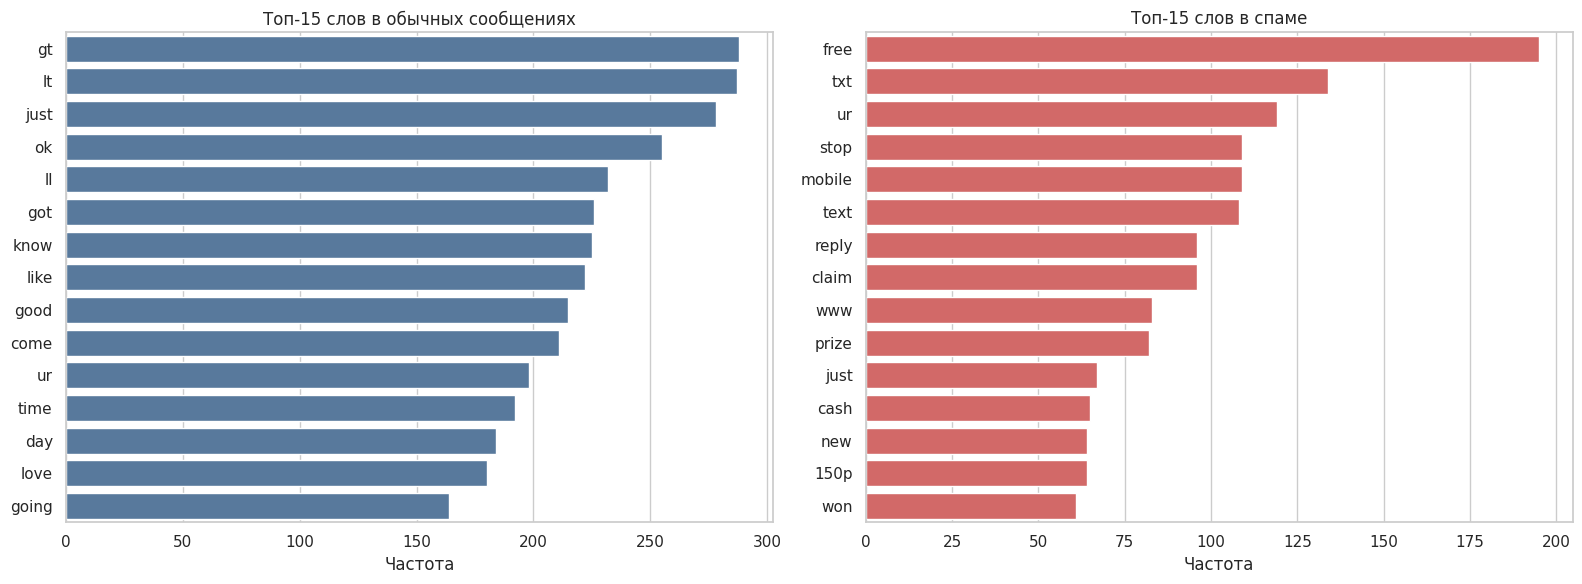

In [ ]:
def get_top_words(series, vectorizer, top_n=15):
    matrix = vectorizer.fit_transform(series)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    tokens = np.array(vectorizer.get_feature_names_out())
    top_idx = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({"token": tokens[top_idx], "count": counts[top_idx]})


ham_top = get_top_words(
    df.loc[df["label"] == "ham", "text_clean_stop"],
    CountVectorizer(min_df=2),
    top_n=15,
)
spam_top = get_top_words(
    df.loc[df["label"] == "spam", "text_clean_stop"],
    CountVectorizer(min_df=2),
    top_n=15,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=ham_top, x="count", y="token", ax=axes[0], color="#4C78A8")
axes[0].set_title("Топ-15 слов в обычных сообщениях")
axes[0].set_xlabel("Частота")
axes[0].set_ylabel("")

sns.barplot(data=spam_top, x="count", y="token", ax=axes[1], color="#E45756")
axes[1].set_title("Топ-15 слов в спаме")
axes[1].set_xlabel("Частота")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Вывод.** В обычных сообщениях преобладают короткие бытовые слова, а в спаме сильнее видны рекламные маркеры: `free`, `txt`, `claim`, `mobile`, `stop`, `reply`, `win`. Это хороший сигнал, что текстовые признаки действительно должны помогать классификации.


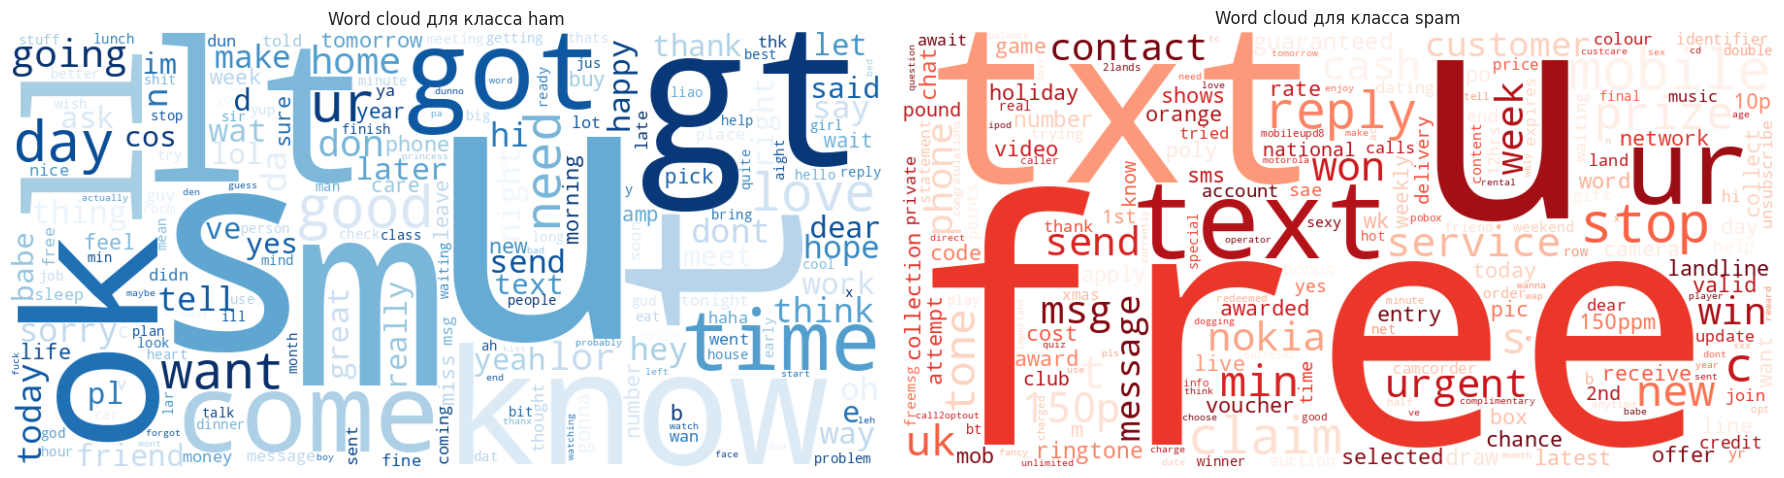

In [ ]:
wc_params = {
    "width": 900,
    "height": 450,
    "background_color": "white",
    "collocations": False,
}

ham_cloud = WordCloud(**wc_params, colormap="Blues").generate(
    " ".join(df.loc[df["label"] == "ham", "text_clean_stop"])
)
spam_cloud = WordCloud(**wc_params, colormap="Reds").generate(
    " ".join(df.loc[df["label"] == "spam", "text_clean_stop"])
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(ham_cloud, interpolation="bilinear")
axes[0].set_title("Word cloud для класса ham")
axes[0].axis("off")

axes[1].imshow(spam_cloud, interpolation="bilinear")
axes[1].set_title("Word cloud для класса spam")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Облака слов дают быстрый визуальный итог предыдущего шага.


## 3. Деление на обучающий и тестовый датасет

Используем:
- деление на обучающий и тестовый наборы в отношении 80/20;
- фиксированный `random_state=42` для воспроизводимости результатов.


In [ ]:
X_basic = df["text_clean_basic"]
X_stop = df["text_clean_stop"]
y = df["label"]

X_train_basic, X_test_basic, y_train, y_test = train_test_split(
    X_basic,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

X_train_stop, X_test_stop, y_train_stop, y_test_stop = train_test_split(
    X_stop,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Train size:", len(X_train_basic))
print("Test size:", len(X_test_basic))
print("Распределение классов в train:")
display(y_train.value_counts(normalize=True).rename("share").mul(100).round(2))


Train size: 4135
Test size: 1034
Распределение классов в train:


,share
label,
ham,87.3800
spam,12.6200


**Вывод.** Разбиение получилось стратифицированным: доли классов в обучающей и тестовой выборках практически совпадают с общим датасетом. Это важно, чтобы модель проверялась на данных с той же структурой дисбаланса, что и в исходном датасете.


## 4. Сравнение моделей и векторизаций

Напишем функцию для подсчета метрик любой комбинации предобработки, векторизатора и модели.

In [ ]:
def evaluate_pipeline(name, vectorizer, model, X_train, X_test, y_train, y_test, preprocessing):
    pipe = Pipeline(
        [
            ("vectorizer", vectorizer),
            ("model", model),
        ]
    )
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    metrics = {
        "experiment": name,
        "preprocessing": preprocessing,
        "vectorizer": vectorizer.__class__.__name__,
        "model": model.__class__.__name__,
        "accuracy": accuracy_score(y_test, preds),
        "precision_spam": precision_score(y_test, preds, pos_label="spam"),
        "recall_spam": recall_score(y_test, preds, pos_label="spam"),
        "f1_spam": f1_score(y_test, preds, pos_label="spam"),
        "pipeline": pipe,
    }
    return metrics


Сравниваем:

- `CountVectorizer`
- `TfidfVectorizer`

и три модели:

- `Multinomial Naive Bayes`
- `Logistic Regression`
- `Linear SVM`


In [ ]:
baseline_results = []

baseline_experiments = [
    ("count_nb", CountVectorizer(), MultinomialNB()),
    ("count_lr", CountVectorizer(), LogisticRegression(max_iter=3000, random_state=42)),
    ("count_svm", CountVectorizer(), LinearSVC(random_state=42)),
    ("tfidf_nb", TfidfVectorizer(), MultinomialNB()),
    ("tfidf_lr", TfidfVectorizer(), LogisticRegression(max_iter=3000, random_state=42)),
    ("tfidf_svm", TfidfVectorizer(), LinearSVC(random_state=42)),
]

for name, vectorizer, model in baseline_experiments:
    baseline_results.append(
        evaluate_pipeline(
            name=name,
            vectorizer=vectorizer,
            model=model,
            X_train=X_train_basic,
            X_test=X_test_basic,
            y_train=y_train,
            y_test=y_test,
            preprocessing="basic_clean",
        )
    )

baseline_df = (
    pd.DataFrame(baseline_results)
    .drop(columns=["pipeline"])
    .sort_values("f1_spam", ascending=False)
    .reset_index(drop=True)
)
display(baseline_df[["vectorizer", "model", "accuracy", "precision_spam", "recall_spam", "f1_spam"]])


,vectorizer,model,accuracy,precision_spam,recall_spam,f1_spam
0,CountVectorizer,MultinomialNB,0.9855,0.9754,0.9084,0.9407
1,CountVectorizer,LinearSVC,0.9845,1.0000,0.8779,0.9350
2,TfidfVectorizer,LinearSVC,0.9816,0.9828,0.8702,0.9231
3,CountVectorizer,LogisticRegression,0.9797,0.9911,0.8473,0.9136
4,TfidfVectorizer,LogisticRegression,0.9671,0.9899,0.7481,0.8522
5,TfidfVectorizer,MultinomialNB,0.9516,1.0000,0.6183,0.7642


**Вывод.** По метрике `F1` для класса `spam` лучше всего себя показывают комбинации с `CountVectorizer`, а абсолютным лидером в этом наборе становится `Multinomial Naive Bayes`. Это хороший пример того, что для текстов не всегда побеждает более "сложный" подход: простые методы тоже могут работать очень сильно.


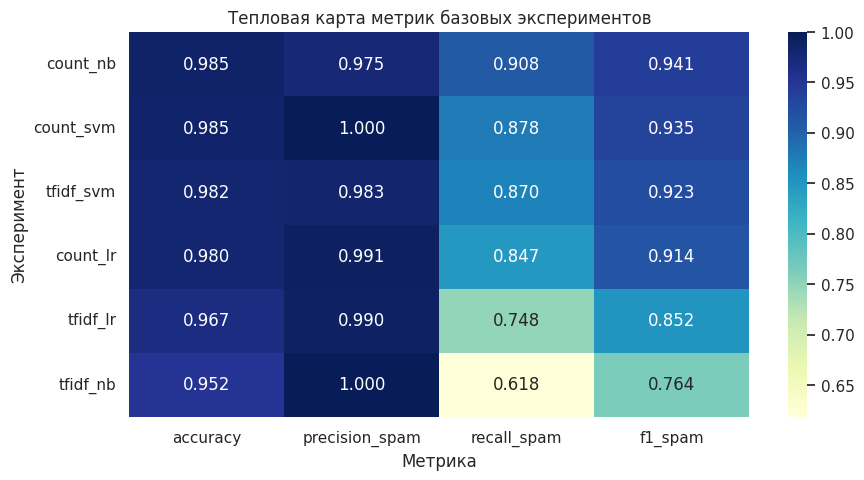

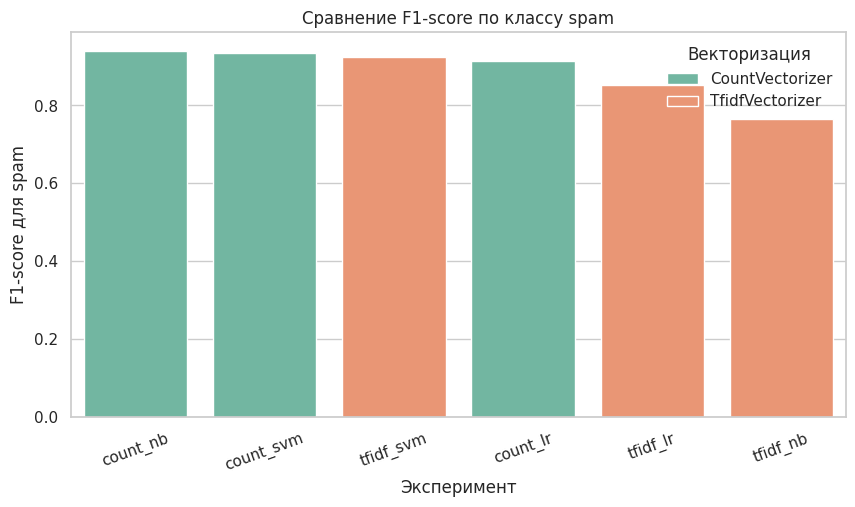

In [ ]:
metric_cols = ["accuracy", "precision_spam", "recall_spam", "f1_spam"]

plt.figure(figsize=(10, 5))
sns.heatmap(
    baseline_df.set_index("experiment")[metric_cols],
    annot=True,
    cmap="YlGnBu",
    fmt=".3f",
)
plt.title("Тепловая карта метрик базовых экспериментов")
plt.xlabel("Метрика")
plt.ylabel("Эксперимент")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=baseline_df,
    x="experiment",
    y="f1_spam",
    hue="vectorizer",
    dodge=False,
)
plt.title("Сравнение F1-score по классу spam")
plt.xlabel("Эксперимент")
plt.ylabel("F1-score для spam")
plt.xticks(rotation=20)
plt.legend(title="Векторизация")
plt.show()


**Вывод.** Графики подтверждают таблицу: разница между лучшими моделями небольшая, но `Naive Bayes + CountVectorizer` выглядит наиболее сбалансированным вариантом по `precision` и `recall`. У `TF-IDF + Naive Bayes` видно слабое место: очень высокая точность, но заметно более низкий `recall`, то есть часть спама модель пропускает.


## 5. Дополнительные эксперименты

Проверим:

- влияние удаления стоп-слов
- влияние `class_weight='balanced'`, что особенно уместно из-за дисбаланса классов.


In [ ]:
extra_results = []

extra_experiments = [
    (
        "count_nb_stop",
        CountVectorizer(),
        MultinomialNB(),
        X_train_stop,
        X_test_stop,
        y_train_stop,
        y_test_stop,
        "basic_clean_plus_stopwords",
    ),
    (
        "tfidf_lr_stop",
        TfidfVectorizer(),
        LogisticRegression(max_iter=3000, random_state=42),
        X_train_stop,
        X_test_stop,
        y_train_stop,
        y_test_stop,
        "basic_clean_plus_stopwords",
    ),
    (
        "tfidf_svm_stop",
        TfidfVectorizer(),
        LinearSVC(random_state=42),
        X_train_stop,
        X_test_stop,
        y_train_stop,
        y_test_stop,
        "basic_clean_plus_stopwords",
    ),
    (
        "tfidf_lr_balanced",
        TfidfVectorizer(),
        LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"),
        X_train_basic,
        X_test_basic,
        y_train,
        y_test,
        "basic_clean_balanced",
    ),
    (
        "tfidf_svm_balanced",
        TfidfVectorizer(),
        LinearSVC(random_state=42, class_weight="balanced"),
        X_train_basic,
        X_test_basic,
        y_train,
        y_test,
        "basic_clean_balanced",
    ),
]

for args in extra_experiments:
    extra_results.append(
        evaluate_pipeline(
            name=args[0],
            vectorizer=args[1],
            model=args[2],
            X_train=args[3],
            X_test=args[4],
            y_train=args[5],
            y_test=args[6],
            preprocessing=args[7],
        )
    )

extra_df = (
    pd.DataFrame(extra_results)
    .drop(columns=["pipeline"])
    .sort_values("f1_spam", ascending=False)
    .reset_index(drop=True)
)

display(extra_df)


,experiment,preprocessing,vectorizer,model,accuracy,precision_spam,recall_spam,f1_spam
0,count_nb_stop,basic_clean_plus_stopwords,CountVectorizer,MultinomialNB,0.9855,0.9677,0.9160,0.9412
1,tfidf_svm_balanced,basic_clean_balanced,TfidfVectorizer,LinearSVC,0.9816,0.9667,0.8855,0.9243
2,tfidf_svm_stop,basic_clean_plus_stopwords,TfidfVectorizer,LinearSVC,0.9816,0.9912,0.8626,0.9224
3,tfidf_lr_balanced,basic_clean_balanced,TfidfVectorizer,LogisticRegression,0.9787,0.9225,0.9084,0.9154
4,tfidf_lr_stop,basic_clean_plus_stopwords,TfidfVectorizer,LogisticRegression,0.9603,0.9891,0.6947,0.8161


**Вывод.** Удаление стоп-слов слегка улучшает лучший `Naive Bayes`, но не меняет картину радикально. Балансировка классов у линейных моделей повышает `recall` по спаму, то есть модель начинает находить больше реального спама, но расплачивается за это снижением точности. Для спам-фильтра это важный компромисс, который полезно обсудить на защите.


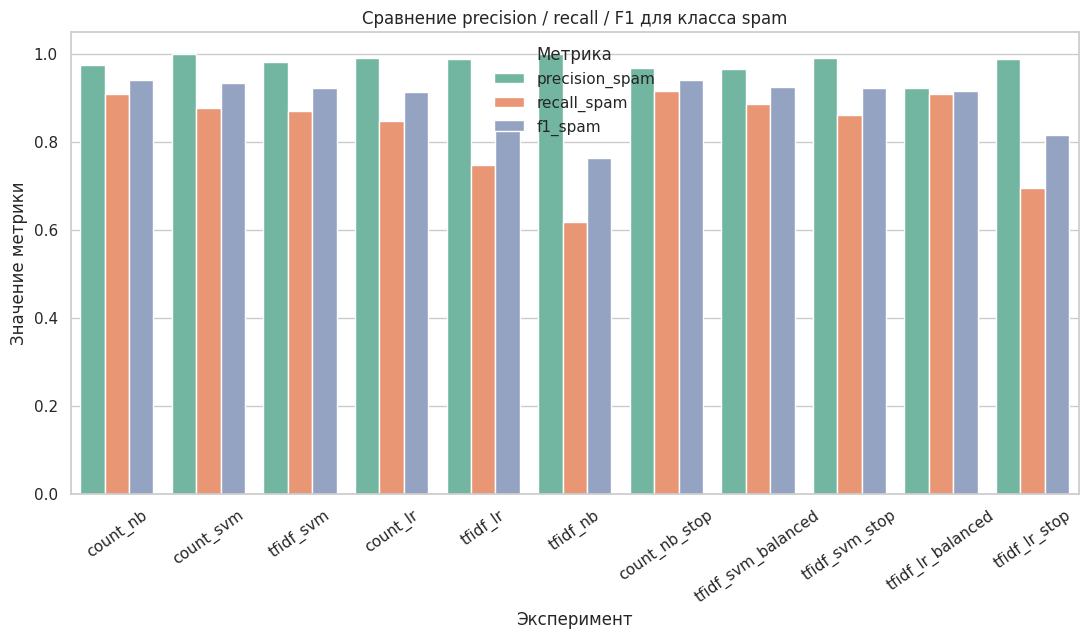

In [ ]:
comparison_for_plot = pd.concat(
    [
        baseline_df[["experiment", "precision_spam", "recall_spam", "f1_spam"]].assign(group="baseline"),
        extra_df[["experiment", "precision_spam", "recall_spam", "f1_spam"]].assign(group="extra"),
    ],
    ignore_index=True,
)

plot_df = comparison_for_plot.melt(
    id_vars=["experiment", "group"],
    value_vars=["precision_spam", "recall_spam", "f1_spam"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x="experiment", y="value", hue="metric")
plt.title("Сравнение precision / recall / F1 для класса spam")
plt.xlabel("Эксперимент")
plt.ylabel("Значение метрики")
plt.xticks(rotation=35)
plt.legend(title="Метрика")
plt.show()


**Вывод.** На графике хорошо видно, как разные решения распределяют акцент между `precision` и `recall`. Если важнее не пропускать спам, балансировка может быть полезной. Если важнее не помечать обычные сообщения как спам, стоит выбирать модель с более высокой точностью.



Проверим, образуются ли в векторном пространстве естественные группы сообщений, и будет ли проявляться деление на спам и не-спам при обучении без учителя.

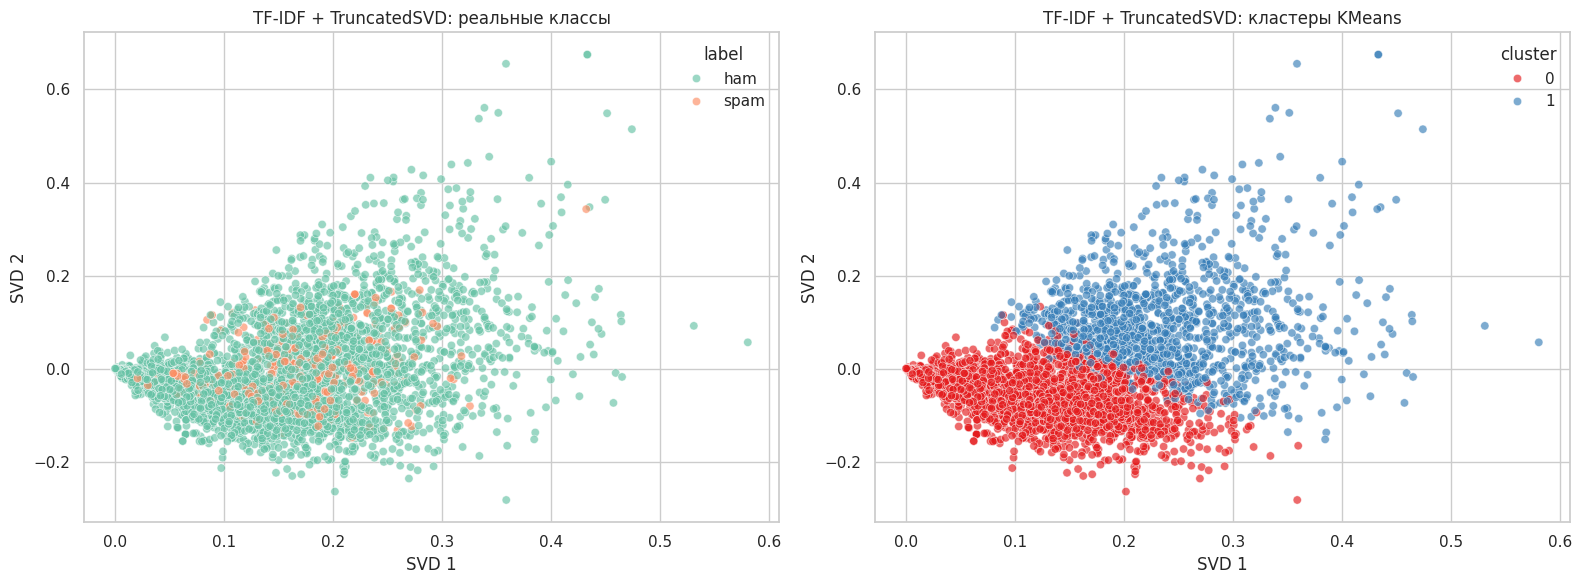

Adjusted Rand Index: -0.0353


label,ham,spam
cluster,,
0,0.8590,0.1410
1,0.9170,0.0830


In [ ]:
tfidf_for_cluster = TfidfVectorizer(min_df=3)
X_cluster = tfidf_for_cluster.fit_transform(df["text_clean_basic"])

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_cluster)

cluster_df = pd.DataFrame(
    {
        "svd_1": X_2d[:, 0],
        "svd_2": X_2d[:, 1],
        "label": df["label"].values,
        "cluster": clusters,
    }
)

ari = adjusted_rand_score(df["label"].map({"ham": 0, "spam": 1}), clusters)
cluster_crosstab = pd.crosstab(cluster_df["cluster"], cluster_df["label"], normalize="index").round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=cluster_df, x="svd_1", y="svd_2", hue="label", alpha=0.65, ax=axes[0])
axes[0].set_title("TF-IDF + TruncatedSVD: реальные классы")
axes[0].set_xlabel("SVD 1")
axes[0].set_ylabel("SVD 2")

sns.scatterplot(data=cluster_df, x="svd_1", y="svd_2", hue="cluster", palette="Set1", alpha=0.65, ax=axes[1])
axes[1].set_title("TF-IDF + TruncatedSVD: кластеры KMeans")
axes[1].set_xlabel("SVD 1")
axes[1].set_ylabel("SVD 2")

plt.tight_layout()
plt.show()

print(f"Adjusted Rand Index: {ari:.4f}")
display(cluster_crosstab)


**Вывод.** Кластеры частично отделяют спам от обычных сообщений, но пллохо. Это ожидаемо: кластеризация без учителя не знает, какие именно различия для нас важны. Поэтому для практической задачи фильтрации спама классификация остаётся основным инструментом, а кластеризация здесь полезна скорее как дополнительная иллюстрация структуры данных.

## 6. Анализ ошибок лучшей модели

На этом датасете лучшей по `F1-score` для класса `spam` оказывается модель:

`CountVectorizer + Multinomial Naive Bayes` с удалением стоп-слов

Рассмотрим её подробнее.


In [ ]:
best_result = extra_results[0]
best_pipeline = best_result["pipeline"]
best_predictions = best_pipeline.predict(X_test_stop)

report_dict = classification_report(
    y_test_stop,
    best_predictions,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose().round(4)
display(report_df)


,precision,recall,f1-score,support
ham,0.9879,0.9956,0.9917,903.0000
spam,0.9677,0.9160,0.9412,131.0000
accuracy,0.9855,0.9855,0.9855,0.9855
macro avg,0.9778,0.9558,0.9665,1034.0000
weighted avg,0.9854,0.9855,0.9853,1034.0000


**Вывод.** У лучшей модели хороший баланс между точностью и полнотой по классу `spam`. Это значит, что модель не только редко ошибается, когда помечает сообщение как спам, но и находит большую часть настоящего спама.


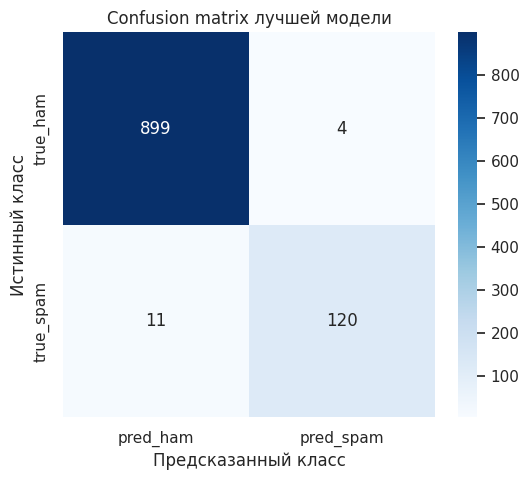

In [ ]:
cm = confusion_matrix(y_test_stop, best_predictions, labels=["ham", "spam"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred_ham", "pred_spam"],
    yticklabels=["true_ham", "true_spam"],
)
plt.title("Confusion matrix лучшей модели")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()


**Вывод.** На confusion matrix видно, что ошибок относительно немного. Основной риск здесь типичен для спам-фильтра: пропустить часть настоящего спама или, наоборот, случайно отправить нормальное сообщение в спам. В нашем случае обе ошибки встречаются редко, но полностью не исчезают.


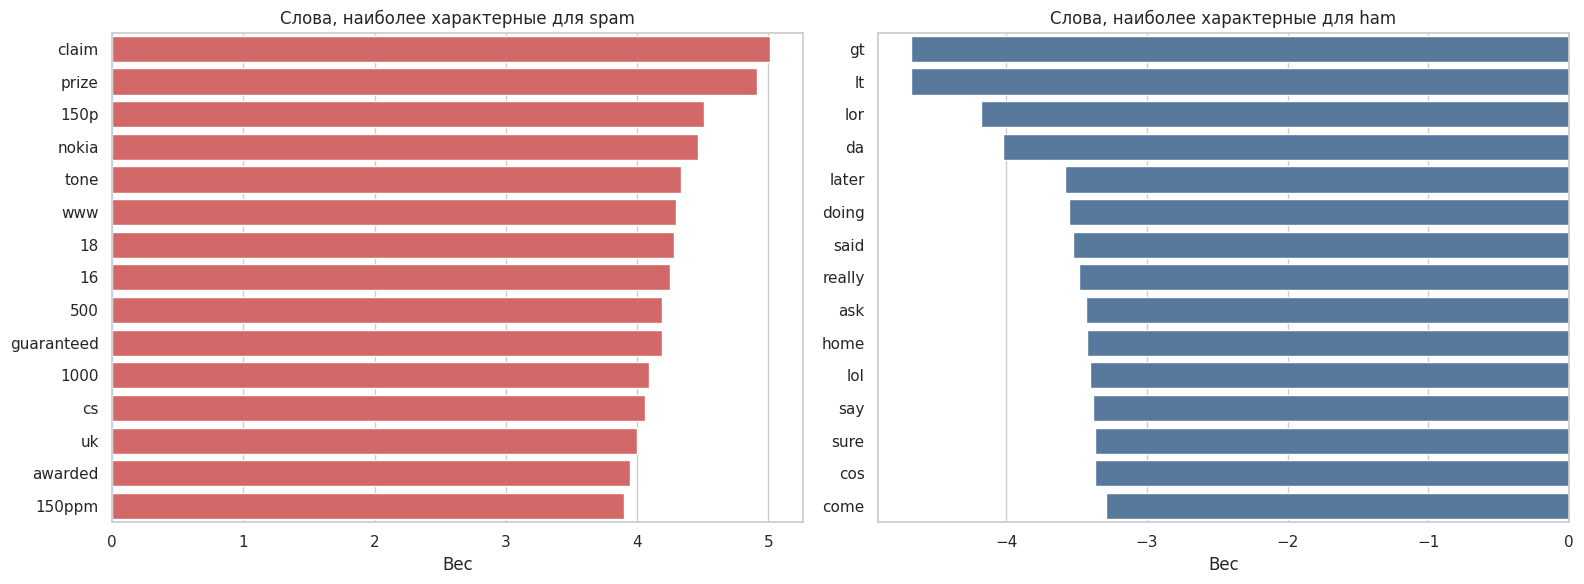

In [ ]:
vectorizer = best_pipeline.named_steps["vectorizer"]
model = best_pipeline.named_steps["model"]
feature_names = np.array(vectorizer.get_feature_names_out())

spam_idx = list(model.classes_).index("spam")
ham_idx = list(model.classes_).index("ham")

log_odds = model.feature_log_prob_[spam_idx] - model.feature_log_prob_[ham_idx]

top_spam_idx = np.argsort(log_odds)[-15:][::-1]
top_ham_idx = np.argsort(log_odds)[:15]

top_spam_features = pd.DataFrame(
    {"token": feature_names[top_spam_idx], "score": log_odds[top_spam_idx]}
)
top_ham_features = pd.DataFrame(
    {"token": feature_names[top_ham_idx], "score": log_odds[top_ham_idx]}
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_spam_features, x="score", y="token", ax=axes[0], color="#E45756")
axes[0].set_title("Слова, наиболее характерные для spam")
axes[0].set_xlabel("Вес")
axes[0].set_ylabel("")

sns.barplot(data=top_ham_features, x="score", y="token", ax=axes[1], color="#4C78A8")
axes[1].set_title("Слова, наиболее характерные для ham")
axes[1].set_xlabel("Вес")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Вывод.** Модель опирается на вполне интерпретируемые слова-маркеры.


Покажем сообщения, на которых лучшая модель совершила ошибку.

In [ ]:
proba_spam = best_pipeline.predict_proba(X_test_stop)[:, spam_idx]

error_df = pd.DataFrame(
    {
        "text_original": X_test_basic.reset_index(drop=True),
        "text_processed": X_test_stop.reset_index(drop=True),
        "true_label": y_test_stop.reset_index(drop=True),
        "pred_label": pd.Series(best_predictions),
        "spam_probability": proba_spam,
    }
)

false_positives = (
    error_df[(error_df["true_label"] == "ham") & (error_df["pred_label"] == "spam")]
    .sort_values("spam_probability", ascending=False)
    .head(5)
)
false_negatives = (
    error_df[(error_df["true_label"] == "spam") & (error_df["pred_label"] == "ham")]
    .sort_values("spam_probability", ascending=True)
    .head(5)
)

print("Ложные срабатывания: обычные сообщения, которые модель приняла за спам")
display(false_positives[["true_label", "pred_label", "spam_probability", "text_original"]])

print("Пропущенный спам: спам-сообщения, которые модель приняла за обычные")
display(false_negatives[["true_label", "pred_label", "spam_probability", "text_original"]])


Ложные срабатывания: обычные сообщения, которые модель приняла за спам


,true_label,pred_label,spam_probability,text_original
827,ham,spam,0.9456,nokia phone is lovly
739,ham,spam,0.8778,hey great deal farm tour 9am to 5pm 95 pax 50 deposit by 16 may
327,ham,spam,0.7807,k k sms chat with me
1006,ham,spam,0.6463,what number do u live at is it 11


Пропущенный спам: спам-сообщения, которые модель приняла за обычные


,true_label,pred_label,spam_probability,text_original
486,spam,ham,0.0000,in the simpsons movie released in july 2007 name the band that died at the start of the film a green day b blue day c red day send a b or c
437,spam,ham,0.0000,babe u want me dont u baby im nasty and have a thing 4 filthyguys fancy a rude time with a sexy bitch how about we go slo n hard txt xxx...
544,spam,ham,0.0019,xmas new years eve tickets are now on sale from the club during the day from 10am till 8pm and on thurs fri sat night this week they re ...
308,spam,ham,0.0075,hi its lucy hubby at meetins all day fri i will b alone at hotel u fancy cumin over pls leave msg 2day 09099726395 lucy x calls 1 minmob...
326,spam,ham,0.0084,missed call alert these numbers called but left no message 07008009200


**Вывод.** Ошибки модели обычно выглядят логично:

- ложные срабатывания появляются у обычных сообщений, которые похожи на рекламу по формулировкам, цифрам или структуре
- пропущенный спам возникает там, где текст выглядит слишком разговорным или недостаточно содержит типичные спам-маркеры

Такой анализ помогает показать, что модель не магическая, а работает по наблюдаемым текстовым паттернам.


## 7. Финальные выводы

1. Задача распознавания SMS-спама достаточно хорошо решаема стандартными методами NLP и машинного обучения.
2. После очистки текста и удаления дубликатов мы получили компактный и удобный для анализа корпус из `5169` уникальных сообщений.
3. Датасет несбалансирован: обычных сообщений значительно больше, чем спама, поэтому оценивать модели только по `accuracy` нельзя.
4. В этой работе лучшей оказалась модель `CountVectorizer + Multinomial Naive Bayes` с удалением стоп-слов.
5. Для спам-фильтра особенно важно смотреть на `precision`, `recall` и `F1-score` по классу `spam`, потому что они лучше отражают практическое качество, чем одна только `accuracy`.
6. Балансировка классов помогает повысить полноту по спаму у линейных моделей, но обычно снижает точность, то есть создаёт больше ложных тревог.
7. Ошибки модели в целом интерпретируемы: она путается там, где обычное сообщение похоже на рекламный текст или где спам замаскирован под нейтральную переписку.
8. Дополнительный эксперимент с кластеризацией показывает, что структура в текстах есть, и деление на классы возможно, но для фильтрации спама классификация с обучением с учителем работает лучше.

